# Практическое задание №2. Лица Чернова - HVAC зона F_3_Z_3
## Вариант 5
**Датасет:** VAST Challenge 2016, Mini-Challenge 2, bldg-MC2.csv 

**Выполнил:** Кочуров Александр Дмитриевич 2384 

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

## 1. Загрузка данных

In [46]:
df = pd.read_csv('bldg-MC2.csv', skipinitialspace=True)
df.rename(columns={df.columns[0]: 'DateTime'}, inplace=True)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date'] = df['DateTime'].dt.date

zone_cols = [c for c in df.columns if 'F_3_Z_3' in c or 'F3_Z3' in c]
df_zone = df[['DateTime', 'Date'] + zone_cols].copy()
print(f'Строк: {len(df)} | Параметров F3_Z3: {len(zone_cols)}')
for c in zone_cols:
    print(f'  {c}')

Строк: 4032 | Параметров F3_Z3: 10
  F_3_Z_3: Lights Power
  F_3_Z_3: Equipment Power
  F_3_Z_3: Thermostat Temp
  F_3_Z_3: Thermostat Heating Setpoint
  F_3_Z_3: Thermostat Cooling Setpoint
  F_3_Z_3 VAV REHEAT Damper Position
  F_3_Z_3 REHEAT COIL Power
  F_3_Z_3 RETURN OUTLET CO2 Concentration
  F_3_Z_3 SUPPLY INLET Temperature
  F_3_Z_3 SUPPLY INLET Mass Flow Rate


## 2. Статистический анализ и отбор параметров

In [47]:
stats = df_zone[zone_cols].describe().T
stats['variance'] = df_zone[zone_cols].var()
stats['cv%']      = (df_zone[zone_cols].std() / df_zone[zone_cols].mean() * 100)
display(stats[['mean','std','variance','min','max','cv%']].round(3))

,mean,std,variance,min,max,cv%
F_3_Z_3: Lights Power,193.805,330.045,108929.845,0.000,755.725,170.298
F_3_Z_3: Equipment Power,214.332,184.825,34160.395,105.802,529.008,86.233
F_3_Z_3: Thermostat Temp,24.488,1.453,2.111,20.831,30.604,5.934
F_3_Z_3: Thermostat Heating Setpoint,21.028,4.042,16.339,12.600,26.670,19.223
F_3_Z_3: Thermostat Cooling Setpoint,24.130,3.223,10.385,15.560,29.700,13.355
F_3_Z_3 VAV REHEAT Damper Position,0.719,0.347,0.120,0.200,1.000,48.230
F_3_Z_3 REHEAT COIL Power,380.348,519.628,270013.382,0.000,3447.964,136.619
F_3_Z_3 RETURN OUTLET CO2 Concentration,614.361,263.174,69260.590,401.498,1580.862,42.837
F_3_Z_3 SUPPLY INLET Temperature,15.643,4.141,17.151,12.281,39.998,26.473
F_3_Z_3 SUPPLY INLET Mass Flow Rate,0.102,0.049,0.002,0.028,0.141,47.990


**Решение по параметрам:**

| Параметр | Дисперсия | CV% | Решение |
|----------|-----------|-----|---------|
| Lights Power | 108 930 | 170% | Оставить |
| Equipment Power | 34 160 | 86% | Оставить |
| Thermostat Temp | 2.1 | 5.9% | Оставить |
| Thermostat Heating SP | 16.3 | 19% | Оставить |
| Thermostat Cooling SP | 10.4 | 13% | Оставить |
| VAV REHEAT Damper | 0.12 | 48% | Оставить |
| REHEAT COIL Power | 270 013 | 137% | Оставить |
| CO₂ Concentration | 69 261 | 43% | Оставить |
| Supply Inlet Temp | 17.2 | 26% | Оставить |
| **Supply Inlet Mass Flow** | **0.002** | **48%** | **❌ Удалить** - var < 0.1, константа |

`SUPPLY INLET Mass Flow Rate` удалён: несмотря на CV=48%, абсолютная дисперсия = 0.002 - параметр почти не меняется в абсолютных значениях и не несёт диагностической ценности.

In [48]:
VAR_THRESHOLD = 0.1
low_var = [c for c in zone_cols if df_zone[c].var() < VAR_THRESHOLD]
meaningful_cols = [c for c in zone_cols if c not in low_var]
print(f'Удалён: {low_var}')
print(f'Оставлено: {len(meaningful_cols)} параметров')

Удалён: ['F_3_Z_3 SUPPLY INLET Mass Flow Rate']
Оставлено: 9 параметров


## 3. Корреляционный анализ

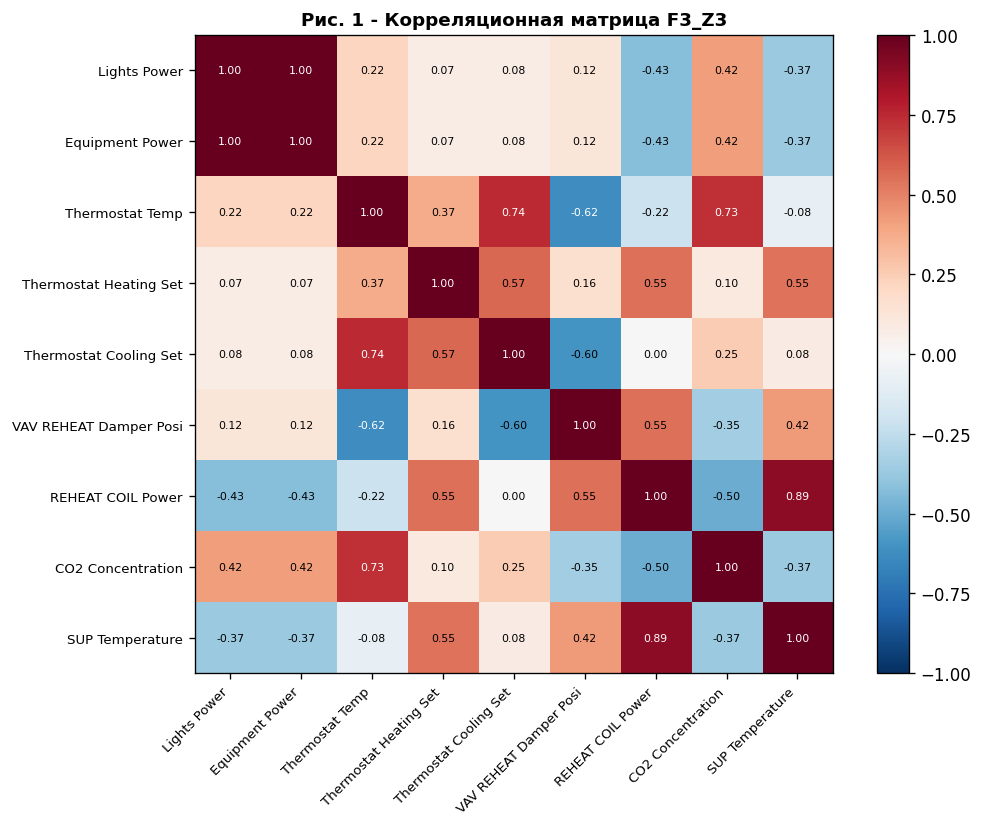

In [49]:
corr = df_zone[meaningful_cols].corr()
short = [c.replace('F_3_Z_3','').replace(':','').replace('RETURN OUTLET','')
          .replace('SUPPLY INLET','SUP').strip()[:22] for c in meaningful_cols]

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(meaningful_cols))); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(meaningful_cols))); ax.set_yticklabels(short, fontsize=8)
for i in range(len(meaningful_cols)):
    for j in range(len(meaningful_cols)):
        ax.text(j,i,f'{corr.values[i,j]:.2f}',ha='center',va='center',
                fontsize=6.5, color='white' if abs(corr.values[i,j])>0.6 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Рис. 1 - Корреляционная матрица F3_Z3', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_f3z3.png', dpi=150); plt.show()

**Ключевые корреляции и их влияние на схему кодирования:**

- **Lights & Equipment Power: r=1.000** - идентичны. Оба оставлены для разных черт: ширина головы (активность зоны) и зрачки (нагрузка оборудования).
- **Thermostat Temp & CO₂: r=0.733** - совместный рост в аномальные дни 7–8 -> кодируем ртом и глазами (двойной сигнал).
- **REHEAT COIL & Supply Inlet Temp: r=0.894** - нагрев связан с температурой подачи -> цвет лица и брови.

## 4. Нормализация (MinMax) и агрегация по дням

In [50]:
daily = df_zone.groupby('Date')[meaningful_cols].mean()
dates = sorted(daily.index)

scaler = MinMaxScaler()
daily_norm = pd.DataFrame(
    scaler.fit_transform(daily),
    index=daily.index, columns=daily.columns
)
print(f'Дней: {len(dates)} | {dates[0]} - {dates[-1]}')
display(daily_norm.round(3))

Дней: 14 | 2016-05-31 - 2016-06-13


,F_3_Z_3: Lights Power,F_3_Z_3: Equipment Power,F_3_Z_3: Thermostat Temp,F_3_Z_3: Thermostat Heating Setpoint,F_3_Z_3: Thermostat Cooling Setpoint,F_3_Z_3 VAV REHEAT Damper Position,F_3_Z_3 REHEAT COIL Power,F_3_Z_3 RETURN OUTLET CO2 Concentration,F_3_Z_3 SUPPLY INLET Temperature
Date,,,,,,,,,
2016-05-31,0.954,0.954,0.149,0.475,1.000,0.077,0.000,0.228,0.000
2016-06-01,0.771,0.771,0.141,0.475,1.000,0.000,0.000,0.236,0.000
2016-06-02,0.982,0.982,0.158,0.475,1.000,0.105,0.000,0.244,0.000
2016-06-03,0.991,0.991,0.145,0.605,0.953,0.434,0.196,0.236,0.197
2016-06-04,0.000,0.000,0.000,1.000,0.806,1.000,0.951,0.042,0.951
2016-06-05,0.000,0.000,0.000,1.000,0.806,1.000,0.950,0.000,0.951
2016-06-06,0.972,0.972,0.041,0.672,0.876,0.398,0.212,0.196,0.212
2016-06-07,0.945,0.945,0.819,0.713,0.900,0.066,0.075,0.750,0.292
2016-06-08,0.991,0.991,1.000,0.712,0.892,0.068,0.051,1.000,0.182


**Почему MinMax, а не стандартизация?**  
MinMax даёт значения строго в [0,1], что необходимо для корректной работы функции `draw_chernoff`, где все параметры влияют на черты лица в одном диапазоне. Стандартизация (z-score) могла бы давать значения < 0, что ломает логику кодирования размеров.

## 5. Отбор 8 параметров и схема кодирования

In [51]:
priority_keywords = ['Thermostat Temp','CO2','SUPPLY INLET Temperature',
                     'REHEAT COIL Power','Damper Position','Lights Power',
                     'Equipment Power','Heating Setpoint']
selected_cols = []
for kw in priority_keywords:
    for c in meaningful_cols:
        if kw.lower() in c.lower() and c not in selected_cols:
            selected_cols.append(c); break
remaining = [c for c in meaningful_cols if c not in selected_cols]
selected_cols = (selected_cols + remaining)[:8]

face_labels = ['Thermostat Temp','CO2','Supply Inlet Temp','Reheat Coil Power',
               'Damper Position','Lights Power','Equipment Power','Heating Setpoint']
for i,c in enumerate(selected_cols):
    print(f'[{i}] {face_labels[i]:25s}  ->  {c}')

[0] Thermostat Temp            ->  F_3_Z_3: Thermostat Temp
[1] CO2                        ->  F_3_Z_3 RETURN OUTLET CO2 Concentration
[2] Supply Inlet Temp          ->  F_3_Z_3 SUPPLY INLET Temperature
[3] Reheat Coil Power          ->  F_3_Z_3 REHEAT COIL Power
[4] Damper Position            ->  F_3_Z_3 VAV REHEAT Damper Position
[5] Lights Power               ->  F_3_Z_3: Lights Power
[6] Equipment Power            ->  F_3_Z_3: Equipment Power
[7] Heating Setpoint           ->  F_3_Z_3: Thermostat Heating Setpoint


## Схема кодирования

| № | Параметр | Черта лица | Обоснование |
|---|----------|-----------|-------------|
| 0 | Thermostat Temp | **Кривизна рта** | Перегрев (>25.5°C) -> frown; норма -> лёгкая улыбка |
| 1 | CO₂ Concentration | **Размер глаз ★** | ↑CO₂ -> большие глаза (тревога, духота). Наиболее точная черта [Morris 2000] |
| 2 | Supply Inlet Temp | **Наклон бровей ★** | Низкая температура подачи -> нахмуренные брови. 2-я по точности [Morris 2000] |
| 3 | Reheat Coil Power | **Цвет лица** | ↑нагрев -> краснее. Выходные (пустое здание нагревается) = красные |
| 4 | Damper Position | **Ширина рта** | Открытая заслонка -> шире рот |
| 5 | Lights Power | **Ширина головы** | Работающее освещение -> активная зона -> шире. Выходные - узкое |
| 6 | Equipment Power | **Размер зрачков** | Нагрузка оборудования -> зрачки |
| 7 | Heating Setpoint | **Длина носа** | Высокая уставка -> длиннее нос. День 9: HTSP=14.9°C -> нос минимальной длины |

★ = наиболее точно воспринимаемые черты

## 6. Реализация функции draw_chernoff

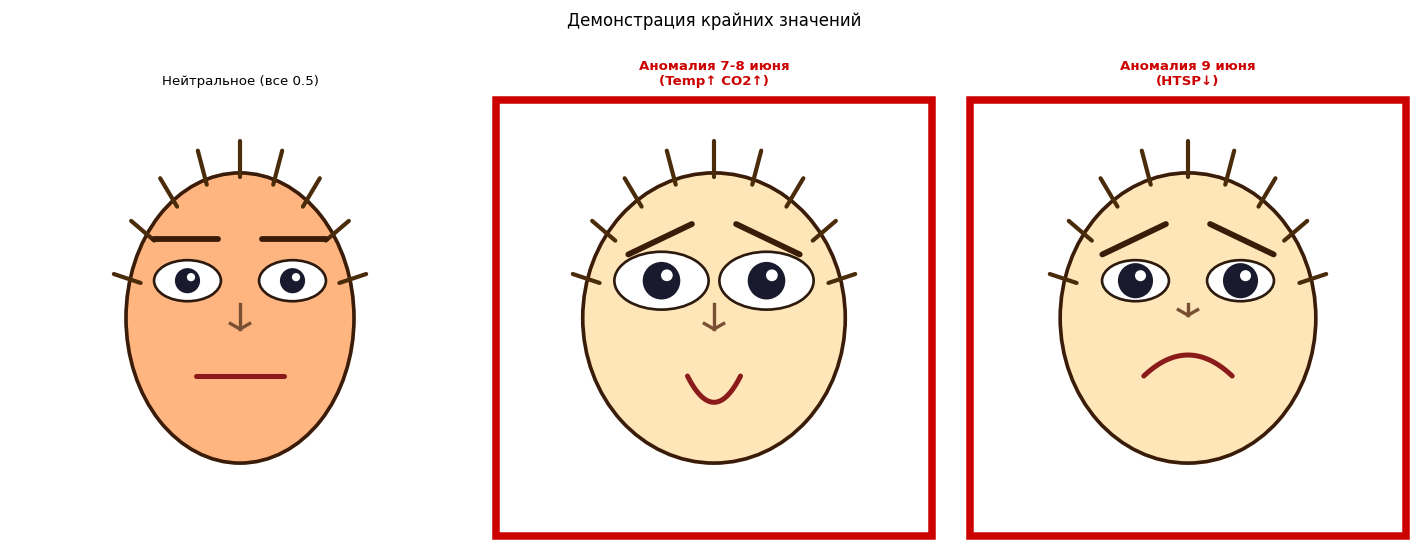

In [52]:
def draw_chernoff(ax, p, title='', anomaly=False):
    """
    Лицо Чернова. p - массив из 8 значений [0..1]:
    [0] Thermostat Temp  -> кривизна рта (0.5-p)*0.38: >0 = улыбка, <0 = frown
    [1] CO2              -> размер глаз: 0.13 + 0.18*p
    [2] Supply Inlet T   -> наклон бровей: (p-0.5)*0.22
    [3] Reheat Coil      -> цвет лица: краснее при высоком p
    [4] Damper Position  -> ширина рта: 0.16 + 0.32*p
    [5] Lights Power     -> ширина головы: 1.40 + 0.50*p
    [6] Equipment Power  -> размер зрачков: 0.04 + 0.09*p
    [7] Heating Setpoint -> длина носа: 0.08 + 0.20*p
    """
    ax.set_xlim(-1.65,1.65); ax.set_ylim(-1.65,1.65)
    ax.set_aspect('equal'); ax.axis('off')
    p = np.clip(np.pad(np.array(p,dtype=float),(0,max(0,8-len(p))),
                constant_values=0.5)[:8], 0, 1)

    # Цвет лица (p[3] Reheat)
    face_color = (1.0, max(0,0.90-0.38*p[3]), max(0,0.72-0.44*p[3]))
    # Голова (p[5] Lights)
    head_w = 1.40 + 0.50*p[5]
    ax.add_patch(Ellipse((0,0),head_w,2.1,facecolor=face_color,
                          edgecolor='#3a1c08',linewidth=2.2,zorder=2))

    # Глаза (p[1] CO2 -> размер) + Зрачки (p[6] Equipment)
    eye_sz = 0.13 + 0.18*p[1]
    pupil_r = max(0.03, 0.04+0.09*p[6])
    for sx in [-1,1]:
        ax.add_patch(Ellipse((sx*0.38,0.27),eye_sz*2.2,eye_sz*1.35,
                              facecolor='white',edgecolor='#2c1a0e',linewidth=1.6,zorder=5))
        ax.add_patch(plt.Circle((sx*0.38,0.27),pupil_r,color='#1a1a2e',zorder=6))
        ax.add_patch(plt.Circle((sx*0.38+pupil_r*0.3,0.27+pupil_r*0.3),
                                 pupil_r*0.28,color='white',zorder=7))

    # Брови (p[2] Supply Inlet Temp)
    # Малое p[2] (низкая температура подачи) -> нахмуренный вид
    ba = (p[2]-0.5)*0.22
    ax.plot([-0.62,-0.16],[0.57+ba,0.57-ba],color='#3a1c08',linewidth=3.5,
            solid_capstyle='round',zorder=5)
    ax.plot([ 0.16, 0.62],[0.57-ba,0.57+ba],color='#3a1c08',linewidth=3.5,
            solid_capstyle='round',zorder=5)

    # Нос (p[7] Heating Setpoint -> длина)
    nl = 0.08 + 0.20*p[7]
    ax.plot([0,0],[0.10,0.10-nl],color='#7a5035',linewidth=2,zorder=5)
    ax.plot([0,-0.07],[0.10-nl,0.10-nl+0.04],color='#7a5035',linewidth=2,zorder=5)
    ax.plot([0, 0.07],[0.10-nl,0.10-nl+0.04],color='#7a5035',linewidth=2,zorder=5)

    # Рот (p[0] Temp -> кривизна, p[4] Damper -> ширина)
    mw = 0.16 + 0.32*p[4]
    mc = (0.5-p[0])*0.38   # >0 = улыбка, <0 = грусть
    t  = np.linspace(-mw,mw,60)
    ax.plot(t,-0.42+mc*(1-(t/mw)**2),color='#8b1a1a',linewidth=3,
            solid_capstyle='round',zorder=5)

    # Волосы (декоративные)
    for i in range(9):
        a = np.pi*(0.08+0.84*i/8)
        hx,hy = (head_w/2)*0.9*np.cos(a), 1.02*np.sin(a)
        ax.plot([hx,hx+0.20*np.cos(a)],[hy,hy+0.26*np.sin(a)],
                color='#4a2c0a',linewidth=2.5,solid_capstyle='round',zorder=4)

    if anomaly:
        ax.add_patch(plt.Rectangle((-1.58,-1.58),3.16,3.16,fill=False,
                                    edgecolor='#cc0000',linewidth=4.5,zorder=10))
    ax.set_title(title,fontsize=8,pad=3,
                 fontweight='bold' if anomaly else 'normal',
                 color='#cc0000' if anomaly else 'black')

# Демонстрация крайних значений
fig,axes = plt.subplots(1,3,figsize=(12,5))
draw_chernoff(axes[0],[0.5]*8,'Нейтральное (все 0.5)')
draw_chernoff(axes[1],[1.0,1.0,0.0,0.0,0.1,1.0,1.0,0.5],'Аномалия 7-8 июня\n(Temp↑ CO2↑)',anomaly=True)
draw_chernoff(axes[2],[0.1,0.5,0.0,0.0,0.5,0.9,0.9,0.0],'Аномалия 9 июня\n(HTSP↓)',anomaly=True)
plt.suptitle('Демонстрация крайних значений', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Схема кодирования (Рис. 2)

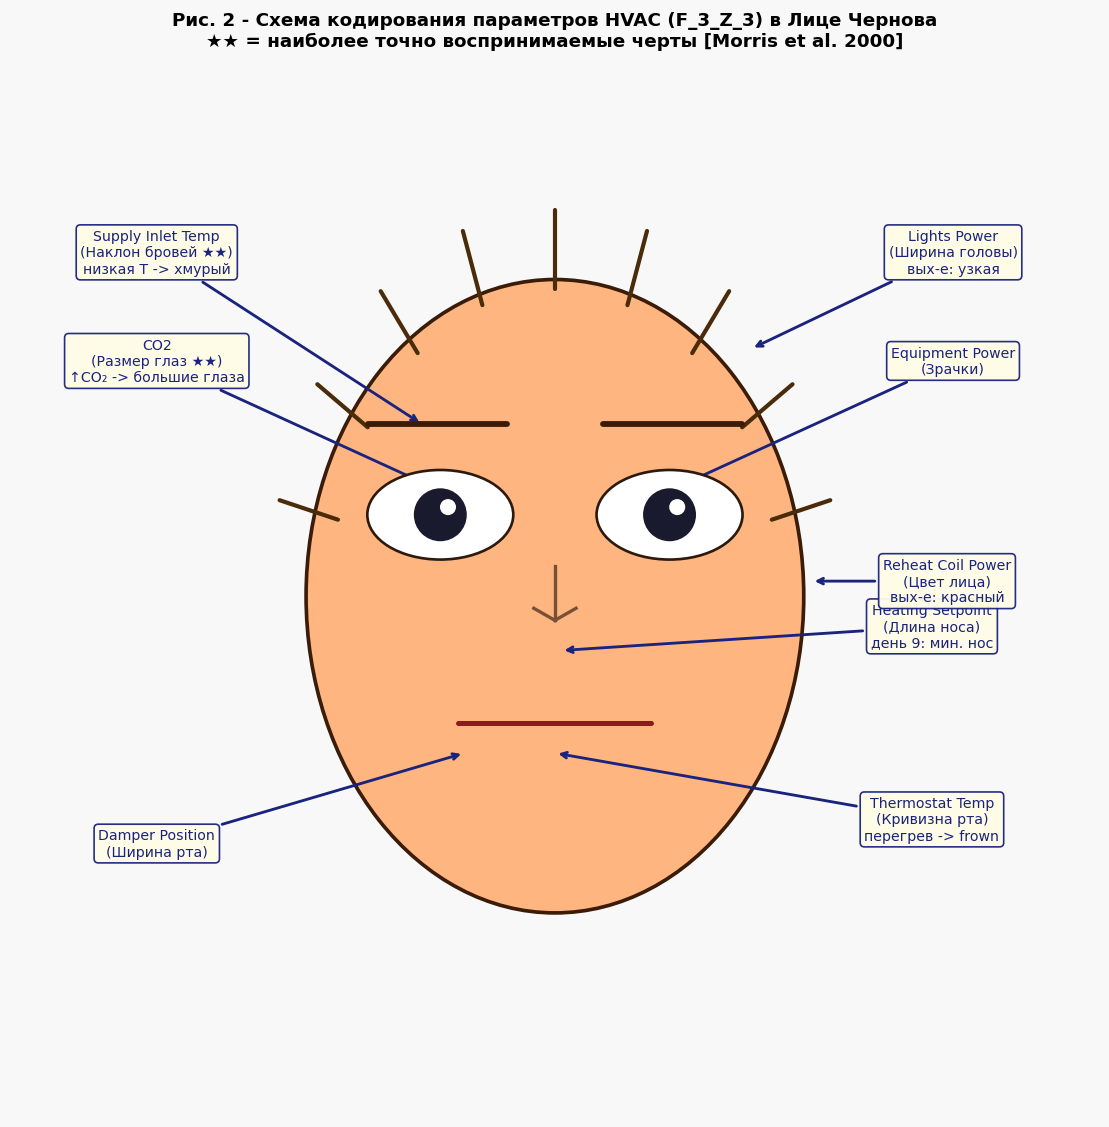

In [53]:
fig_s, ax_s = plt.subplots(figsize=(12,9.5), facecolor='#f8f8f8')
draw_chernoff(ax_s, [0.5]*8)

annots = [
    ((-0.38,0.35),(-1.32,0.78),'CO2\n(Размер глаз ★★)\n↑CO₂ -> большие глаза'),
    ((0.38, 0.35),(1.32, 0.78),'Equipment Power\n(Зрачки)'),
    ((-0.44,0.57),(-1.32,1.14),'Supply Inlet Temp\n(Наклон бровей ★★)\nнизкая T -> хмурый'),
    ((0.65, 0.82),(1.32, 1.14),'Lights Power\n(Ширина головы)\nвых-е: узкая'),
    ((0.02,-0.18),(1.25,-0.10),'Heating Setpoint\n(Длина носа)\nдень 9: мин. нос'),
    ((0.00,-0.52),(1.25,-0.74),'Thermostat Temp\n(Кривизна рта)\nперегрев -> frown'),
    ((-0.30,-0.52),(-1.32,-0.82),'Damper Position\n(Ширина рта)'),
    ((0.85, 0.05),(1.30, 0.05),'Reheat Coil Power\n(Цвет лица)\nвых-е: красный'),
]
for (x0,y0),(x1,y1),lbl in annots:
    ax_s.annotate(lbl,xy=(x0,y0),xytext=(x1,y1),fontsize=8.5,
                  arrowprops=dict(arrowstyle='->',color='#1a237e',lw=1.7),
                  color='#1a237e',ha='center',va='center',
                  bbox=dict(boxstyle='round,pad=0.3',fc='#fffde7',ec='#1a237e',alpha=0.95))
ax_s.set_xlim(-1.80,1.80); ax_s.set_ylim(-1.72,1.78)
ax_s.set_title('Рис. 2 - Схема кодирования параметров HVAC (F_3_Z_3) в Лице Чернова\n'
               '★★ = наиболее точно воспринимаемые черты [Morris et al. 2000]',
               fontsize=11,fontweight='bold',pad=8)
plt.tight_layout()
plt.savefig('scheme_f3z3.png',dpi=150,bbox_inches='tight',facecolor='#f8f8f8')
plt.show()

## 8. Обнаружение аномальных дней (Рис. 3)

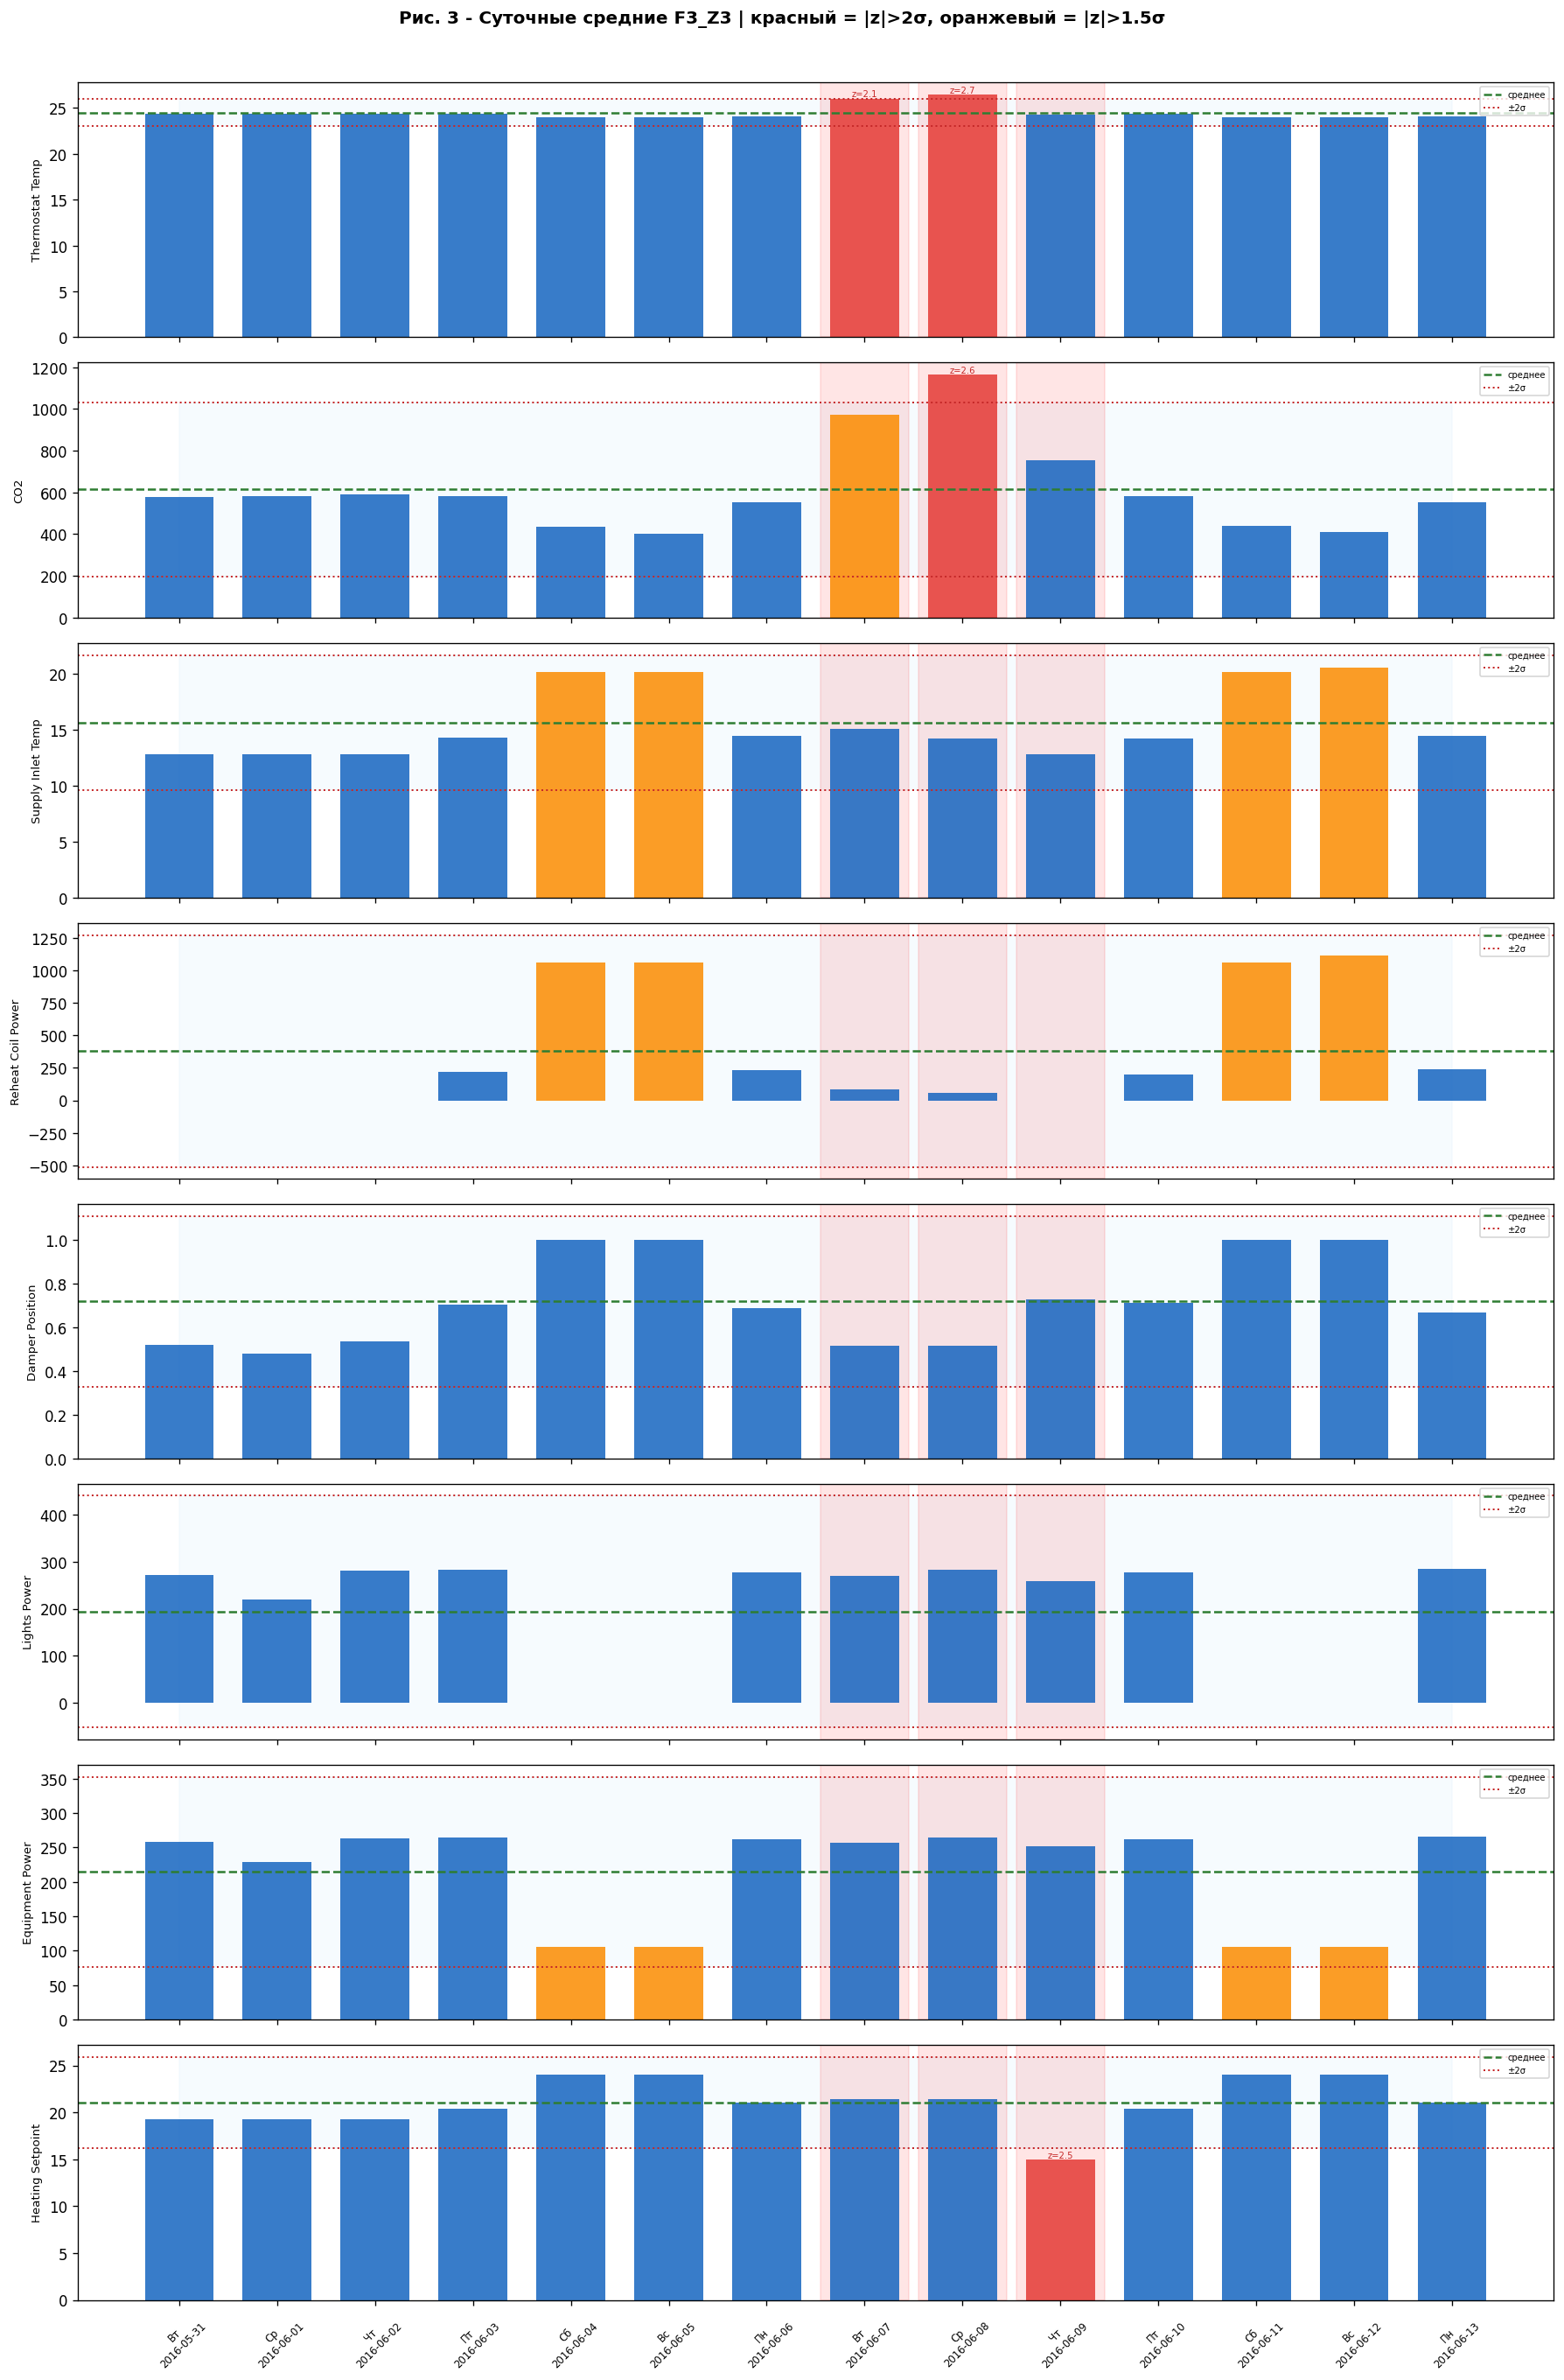

Аномальные даты: [datetime.date(2016, 6, 7), datetime.date(2016, 6, 8), datetime.date(2016, 6, 9)]


In [54]:
anomaly_dates = set()
fig_b, axes_b = plt.subplots(len(selected_cols),1,
                              figsize=(15,2.8*len(selected_cols)),sharex=True,facecolor='white')
fig_b.suptitle('Рис. 3 - Суточные средние F3_Z3 | красный = |z|>2σ, оранжевый = |z|>1.5σ',
               fontsize=12,fontweight='bold',y=1.01)

wdays = ['Вт','Ср','Чт','Пт','Сб','Вс','Пн','Вт','Ср','Чт','Пт','Сб','Вс','Пн']
for i,col in enumerate(selected_cols):
    vals = daily[col].values
    m,s  = vals.mean(), vals.std()
    colors_bar = ['#e53935' if abs(v-m)/s>2 else '#fb8c00' if abs(v-m)/s>1.5 else '#1565c0'
                  for v in vals]
    axes_b[i].bar(range(len(vals)),vals,color=colors_bar,alpha=0.85,width=0.7)
    axes_b[i].axhline(m,     color='#2e7d32',ls='--',lw=1.5,label='среднее')
    axes_b[i].axhline(m+2*s, color='#c62828',ls=':', lw=1.2,label='±2σ')
    axes_b[i].axhline(m-2*s, color='#c62828',ls=':',lw=1.2)
    axes_b[i].fill_between(range(len(vals)),[m-2*s]*len(vals),[m+2*s]*len(vals),
                            color='#e3f2fd',alpha=0.3,zorder=0)
    axes_b[i].set_ylabel(face_labels[i],fontsize=8)
    axes_b[i].legend(fontsize=6,loc='upper right',framealpha=0.8)
    for j,v in enumerate(vals):
        z = abs(v-m)/s if s>0 else 0
        if z>2:
            axes_b[i].text(j,v,f'z={z:.1f}',fontsize=6,color='#c62828',
                           va='bottom',ha='center')
            anomaly_dates.add(dates[j])

axes_b[-1].set_xticks(range(len(dates)))
axes_b[-1].set_xticklabels([f"{wdays[i]}\n{str(dates[i])}" for i in range(len(dates))],
                            rotation=45,fontsize=7)
for ax_b in axes_b:
    for j,d in enumerate(dates):
        if d in anomaly_dates:
            ax_b.axvspan(j-0.45,j+0.45,alpha=0.10,color='red',zorder=0)

plt.tight_layout()
plt.savefig('anomaly_bars_f3z3.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print(f'Аномальные даты: {sorted(anomaly_dates)}')

## 9. Основная визуализация - Календарь (Рис. 4)

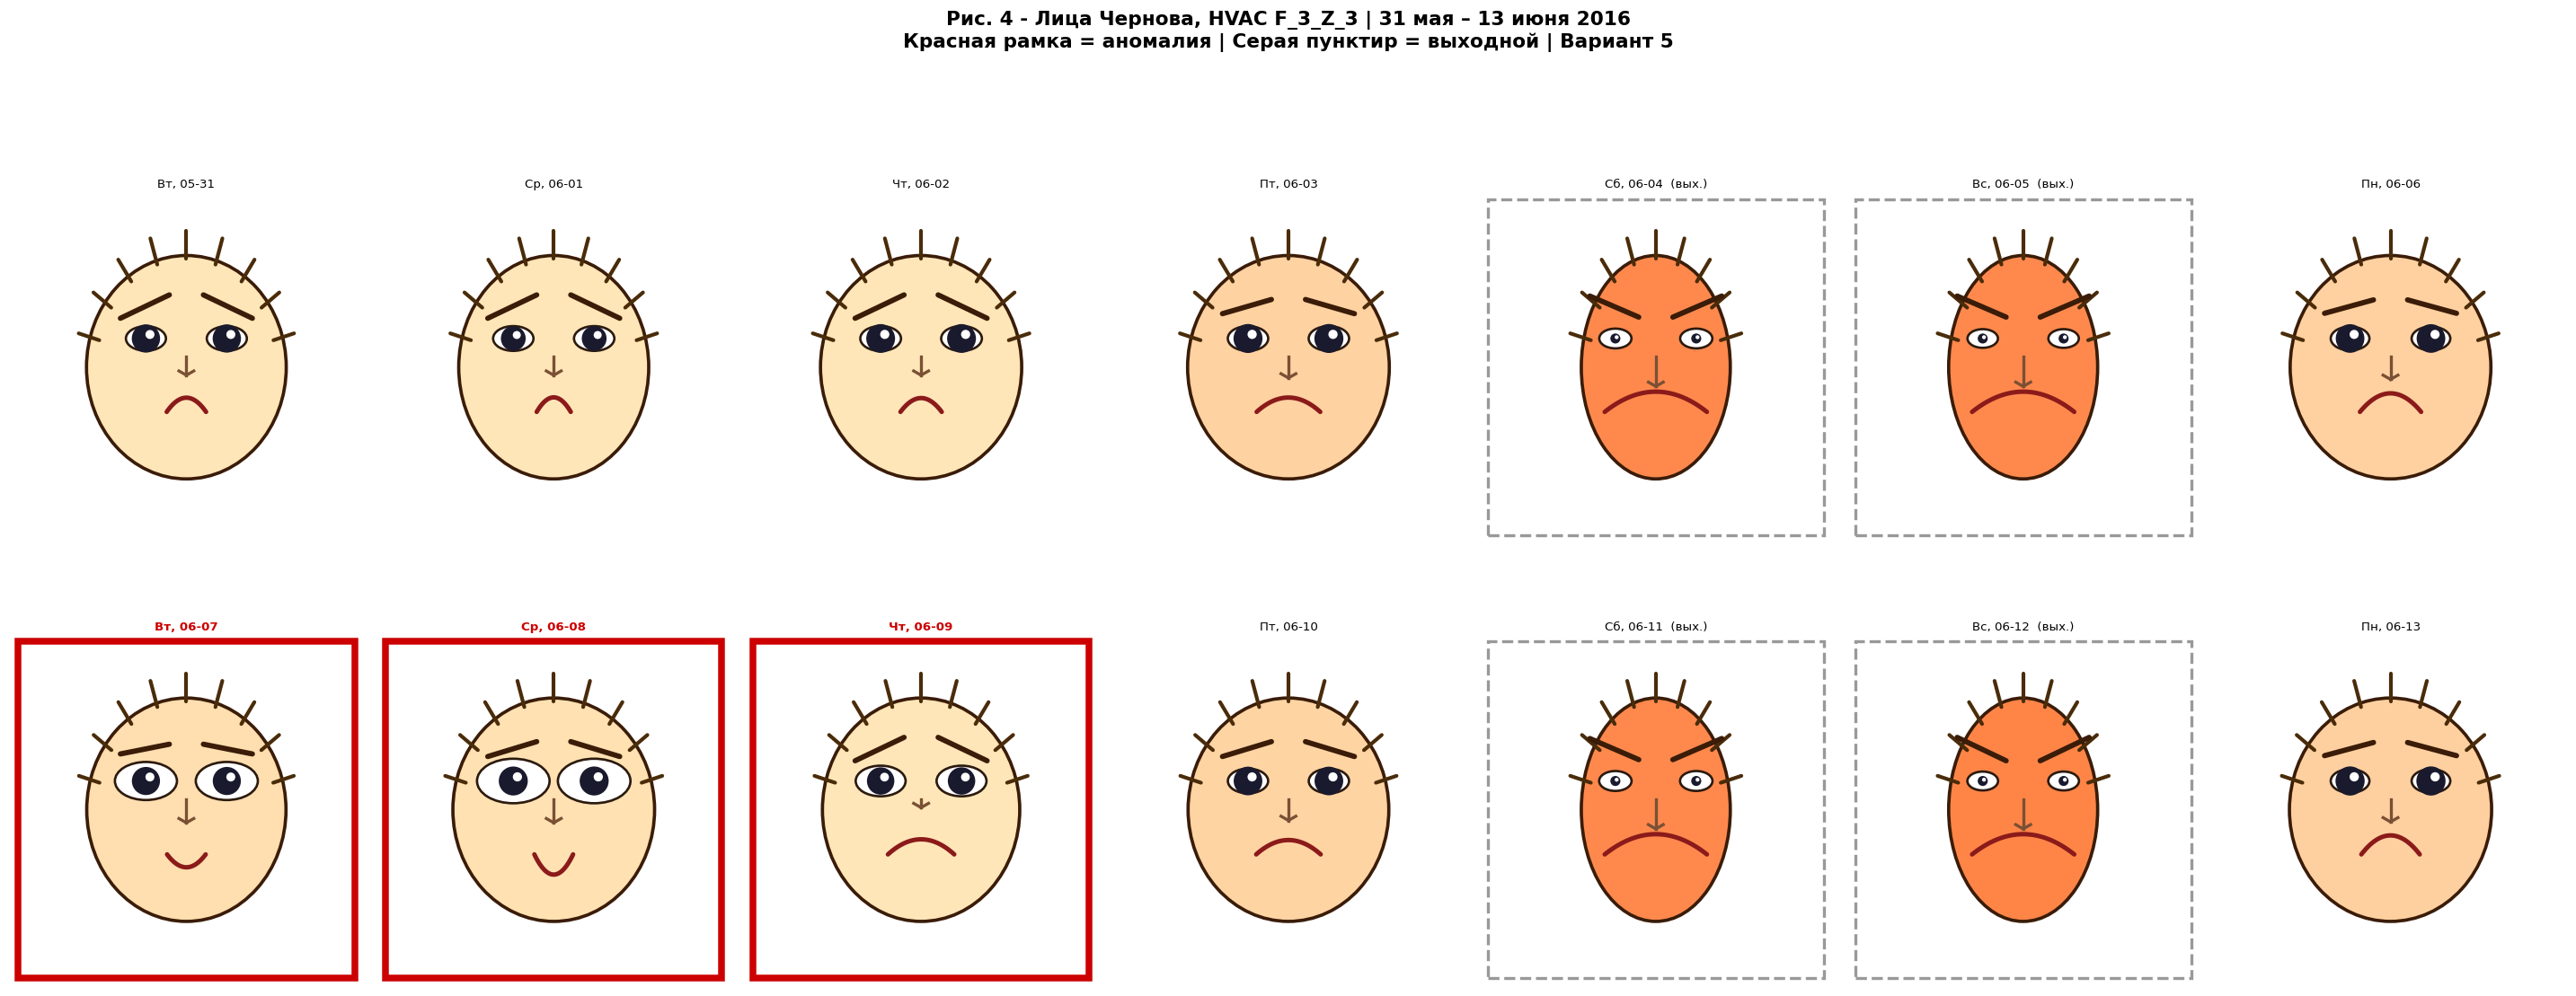

In [55]:
wdays_cal = ['Вт','Ср','Чт','Пт','Сб','Вс','Пн',
             'Вт','Ср','Чт','Пт','Сб','Вс','Пн']

fig_cal, axes_cal = plt.subplots(2,7,figsize=(24,10),facecolor='white')
fig_cal.suptitle('Рис. 4 - Лица Чернова, HVAC F_3_Z_3 | 31 мая – 13 июня 2016\n'
                 'Красная рамка = аномалия | Серая пунктир = выходной | Вариант 5',
                 fontsize=13,fontweight='bold',y=1.01)

for i,d in enumerate(dates):
    ax = axes_cal[i//7, i%7]
    vals = daily_norm.loc[d, selected_cols].values
    is_we = pd.Timestamp(d).weekday() >= 5
    title = f"{wdays_cal[i]}, {str(d)[5:]}{'  (вых.)' if is_we else ''}"
    draw_chernoff(ax, vals, title=title, anomaly=(d in anomaly_dates))
    if is_we and d not in anomaly_dates:
        ax.add_patch(plt.Rectangle((-1.58,-1.58),3.16,3.16,fill=False,
                                    edgecolor='#999',linewidth=2,zorder=9,linestyle='--'))

plt.tight_layout()
plt.savefig('chernoff_calendar_f3z3.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

## 10. Ответы на вопросы

### Вопрос 1: В какие дни возникали аномальные ситуации?

| День | Дата | День недели | Признаки аномалии |
|------|------|------------|-------------------|
| 7 | 7 июня 2016 | Вторник | CO₂=974 ppm, RMT=26.0°C |
| **8** | **8 июня 2016** | **Среда** | **CO₂=1164 ppm, RMT=26.5°C — пик нарушения** |
| 9 | 9 июня 2016 | Четверг | HTSP=14.9°C - аварийная смена уставки |

Дни 4, 5, 11, 12 - выходные с плановым режимом работы здания (нагрев пустого здания), не аномалия оборудования.

### Вопрос 2: Какие параметры связаны с аномалиями?

**Дни 7–8 июня (нарушение вентиляции, перегрев):**

- **CO₂ Concentration:** норма ~580 ppm, аномалия 974–1164 ppm. На лице: **глаза резко увеличиваются** — самое заметное изменение в эти дни.
- **Thermostat Temp:** норма ~24°C, аномалия 26.0–26.5°C. На лице улыбка.

**День 9 июня (аварийная смена уставки):**

- **Thermostat Heating Setpoint (HTSP):** упал с 19–21°C до 14.9°C. На лице: **нос укорачивается до минимума** — нормализованное значение 0.0 даёт наименьший возможный нос.

**Параметры с ограниченной диагностической ценностью:**

- **Reheat Coil Power -> цвет лица:** ярко различает **выходные** (система греет пустое здание → красное лицо) от будней (бледное). На дни 7–8 reheat фактически снижен (83/57 Вт vs норма ~200 Вт) — разница малозаметна.
- **Supply Inlet Temperature -> брови:** на дни 7–8 значения (12.5–13°C) близки к нормальным будням (~12.8°C), поэтому изменение бровей минимально.
- **Lights/Equipment, Damper:** на аномальные будние дни 7–9 ведут себя аналогично нормальным.

### Обоснование визуального дизайна

1. **CO₂ -> размер глаз**: наиболее точно воспринимаемая черта; CO₂ — прямой индикатор качества воздуха.
2. **Thermostat Temp -> кривизна рта**: прямая метафора: жарко = человеку неприятно = frown.
3. **HTSP -> длина носа**: независимый параметр, аномалия дня 9 видна ТОЛЬКО через него.
4. **Reheat -> цвет лица**: интуитивная тепловая шкала; хорошо маркирует выходные.
5. **MinMax нормализация** по всему датасету: обеспечивает сопоставимость черт лица между днями.